In [28]:
"""
Explore Pytorch regularization on simulated 500 MHz data by upsampling pulse from 40 to 500 Mhz and running realistic F domain simulation

We also might explore doing gaussian smoothing of the kernel and signal (same filter) to try to smooth out the noise. Will it help?
Will it degrade our ability to work at higher countrates even if it incerases our confidednce in output

"""

'\nExplore Pytorch regularization on simulated 500 MHz data by upsampling pulse from 40 to 500 Mhz and running realistic F domain simulation\n\nWe also might explore doing gaussian smoothing of the kernel and signal (same filter) to try to smooth out the noise. Will it help?\nWill it degrade our ability to work at higher countrates even if it incerases our confidednce in output\n\n'

In [29]:
import numpy as np
from util.DataGen import nai_pulse, sample_shift_to_phase_shift, continuous_time_trace
from util.Processing import fft_deconvolve
import scipy

import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import circulant
from torch.autograd import Variable
from time import time

device = torch.device("cuda")

Pulse Peak Offset: 9
100 1250


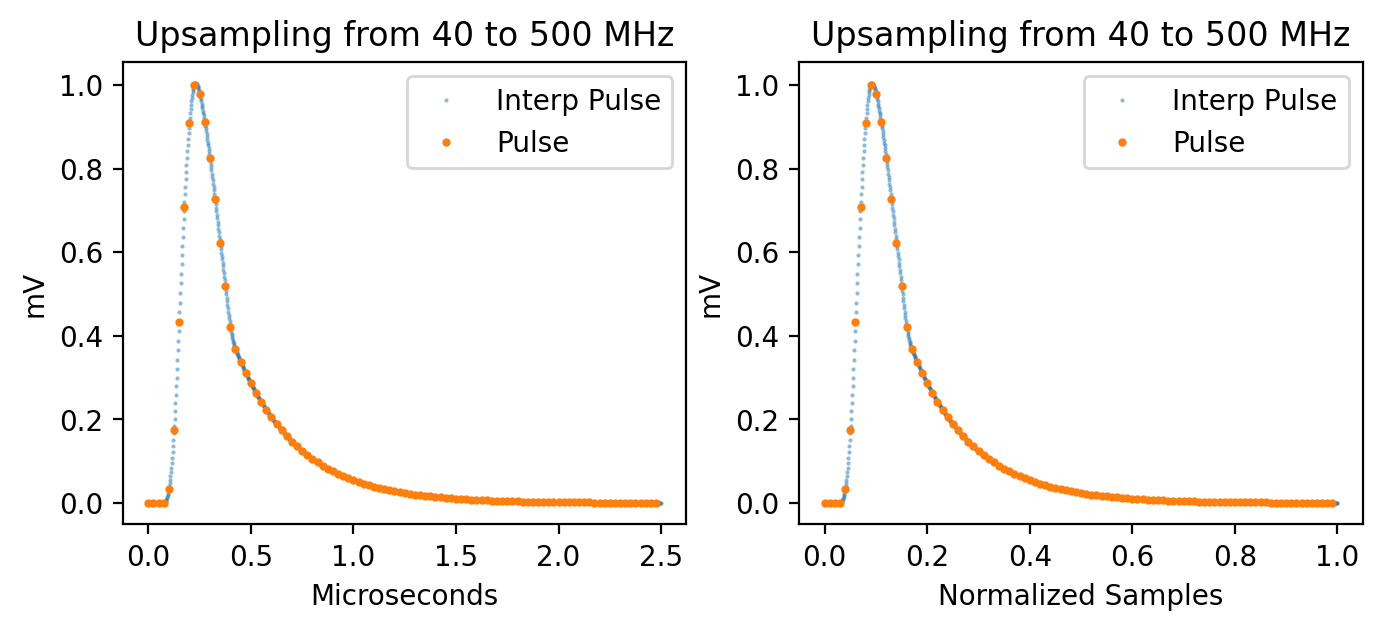

In [30]:
pulse_times, pulse = nai_pulse(1)
pulse_times = pulse_times[:-1]
pulse = pulse[:-1]
print('Pulse Peak Offset:', np.argmax(pulse))

old = 40
new = 500
interp_pulse = scipy.signal.resample_poly(pulse, up=new, down=old)
interp_time = old/new * np.diff(pulse_times[:2]) * np.arange(interp_pulse.size)

print(pulse.size, interp_pulse.size)

fig,axes = plt.subplots(1,2, figsize=(8, 3), dpi=200)
axes[0].plot(1E6*interp_time, interp_pulse, '.', markersize=1, alpha=.5, label= 'Interp Pulse')
axes[0].plot(1E6*pulse_times, pulse, '.', markersize=4, label='Pulse')
axes[0].set_xlabel('Microseconds')
axes[0].set_title('Upsampling from 40 to 500 MHz')
axes[0].set_ylabel('mV')
# axes[0].set_xlim(0, 3)
axes[0].legend()

axes[1].plot(np.arange(interp_pulse.size)/interp_pulse.size, interp_pulse, '.', markersize=1, alpha=.5, label='Interp Pulse')
axes[1].plot(np.arange(pulse.size)/pulse.size, pulse, '.', markersize=4, label='Pulse')
axes[1].set_xlabel('Normalized Samples')
axes[1].set_title('Upsampling from 40 to 500 MHz')
axes[1].set_ylabel('mV')
axes[1].legend()

del pulse_times, pulse # make sure we are not using them

50 50 50
(1252,)
kernel sum 160.84872004310049
Trace Size: 6250


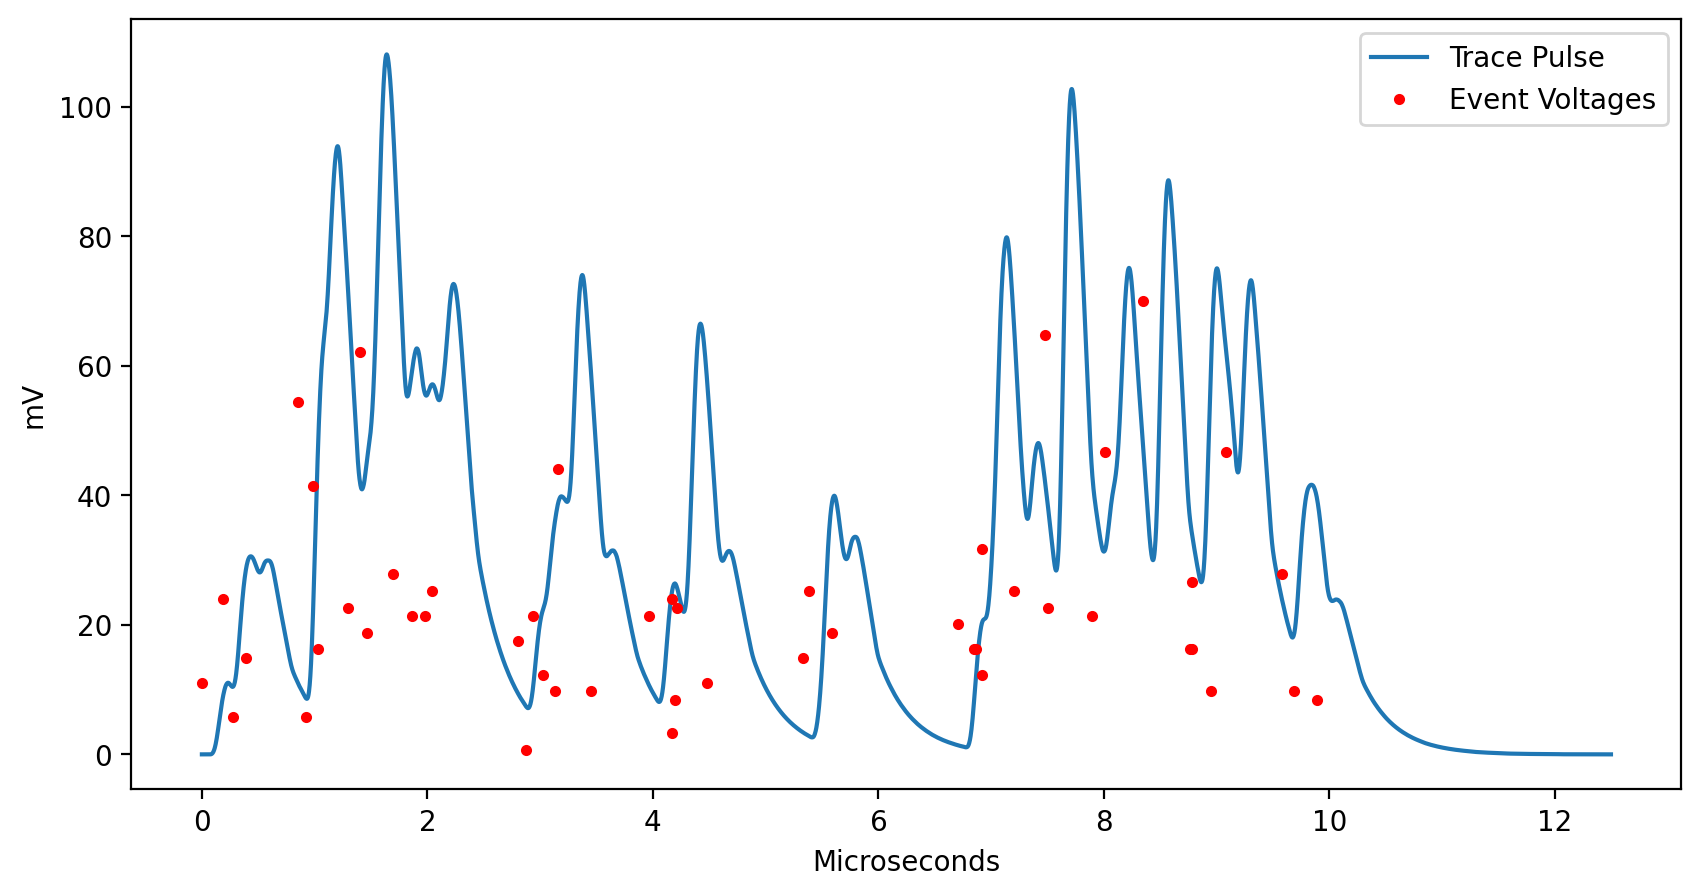

In [31]:
#determined by trial and error to match energy range of instrument on THOR data.
# modified for sampling rate difference with HERA

keV_per_area = .147
mV_per_ADC = 1000/4096 * (500/40) # temp constant while using 40MHz pulse...
baseline = 100
basenoise = 0 #units mV
bits = 12
clip = 1000

# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007 #.7 #mean of the TGF trace distribution
std = 0 #.5 #determines the amount of assymetry in the TGF trace distribution

response_file = '../original/NaI_Response'
spectrum = np.loadtxt(response_file, usecols=(1), dtype=float) # histogram counts...
binenergies = np.loadtxt(response_file, usecols=(0), dtype=float) * 1e3 # [KeV]

fs = 500E6 # new HERA sampling rate
out = continuous_time_trace(interp_pulse, binenergies, spectrum, mV_per_ADC, keV_per_area,
                            fs=fs, count_rate=5E6, total_time=1E-5, trace_type='constant',
                            lognormal_mean=mean, lognormal_std=std, lognormal_fwhm=fwhm,
                            baseline=basenoise, basenoise=basenoise, bits=bits, clip_magnitude=clip, 
                            seed=1,)

sample_t, sample_index, trace, event_times, event_voltages, event_energies = out

print('Trace Size:', trace.size)

trace_gt0 = trace[trace>0]

plt.figure(figsize=(10,5), dpi=200)
plt.plot(1E6*sample_t, trace, label='Trace Pulse')
plt.plot(1E6 * event_times, event_voltages, 'r.', label='Event Voltages')
# plt.plot(1E6*interp_time, interp_pulse * np.max(trace), '.', markersize=1, alpha=.5, label='Interp Pulse')
plt.xlabel('Microseconds')
plt.ylabel('mV')
plt.legend()


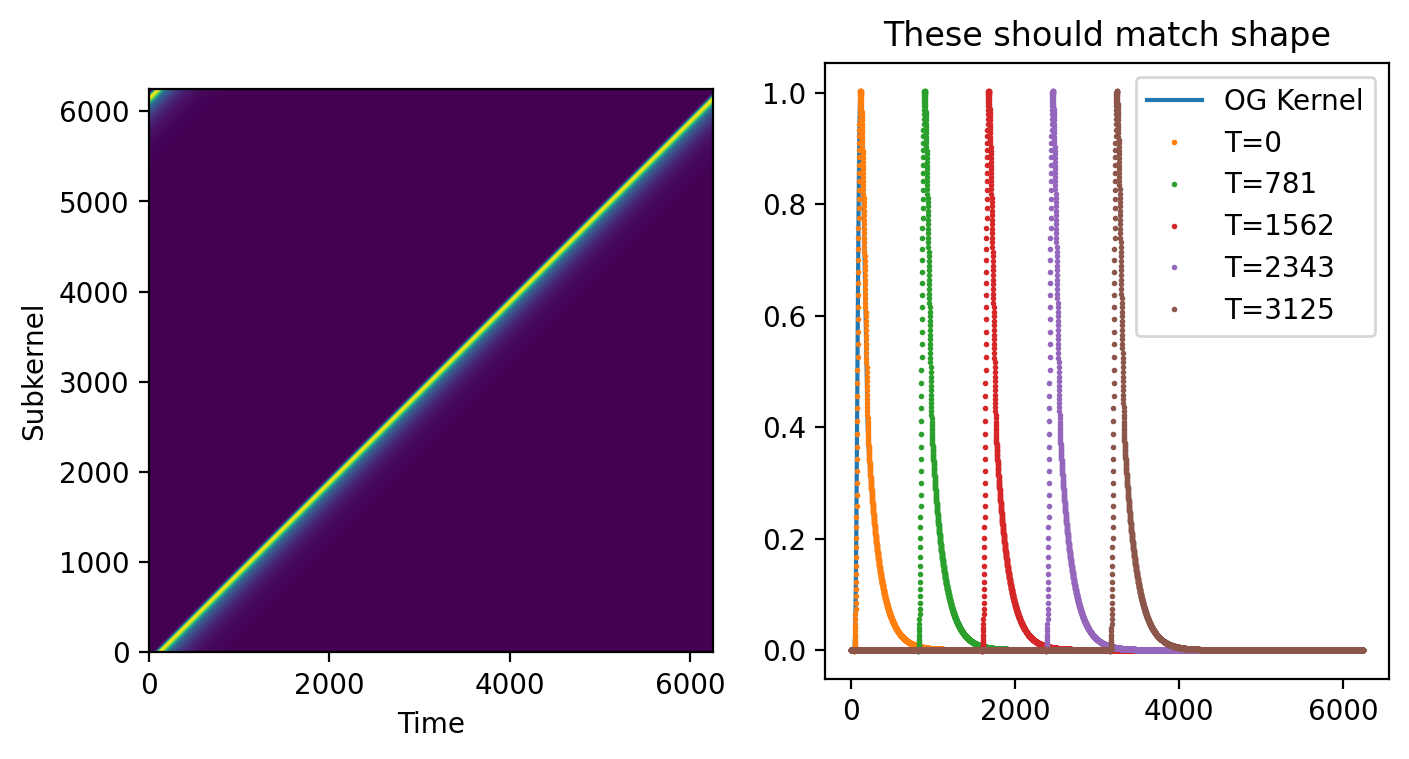

In [32]:
def dense_double_padded_circulant(kernel, size, show=False):
    # Produces C of shape [Time, channels]. Unforunately, Time=channels
    # so plotting is used to double-check they are correct...
    
    assert size > kernel.size, 'Circulant Size {} not > Kernel Size {},'.format(size, kernel.size)
    # Square matrix
    # assuming it is to be used with double padded trace
    C_ = circulant(np.concatenate((kernel, np.zeros(size - kernel.size))))
    # Orientation does not matter as long as the kernels face the right direction!!!
    
    # Zero the padded regions
    # DO NOT USE
    # C_[:kernel.size, :] = 0
    # C_[size - kernel.size:, :] = 0
    
    # USE
    # C_[:, :kernel.size] = 0
    # C_[:, size - kernel.size:] = 0
    
    if show:
        fig, axes = plt.subplots(1,2,figsize=(8,4), dpi=200)
        axes[0].imshow(C_.T, origin='lower') 
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel('Subkernel')
        
        axes[1].plot(kernel, label='OG Kernel')
        # needs to be [time, kernel n]
        for i in np.floor(np.linspace(0, C_.shape[1]//2, 5)).astype(int):
            axes[1].plot(C_[:,i], '.', label='T={}'.format(i), markersize=2)
            
        axes[1].set_title('These should match shape')
        axes[1].legend()
        plt.show()
    
    return C_

C_numpy = dense_double_padded_circulant(interp_pulse, trace.size, show=True)
print()


In [33]:
# # Y=CX. Y:Trace, X, deconv. 
# # Y' = CX'
# # Loss = Y - Y'
# 
# Y = Variable(torch.tensor(trace), requires_grad=True).to(device)
# X = Variable(.05 * torch.ones_like(Y), requires_grad=True).to(device)
# C = Variable(torch.tensor(C_numpy), requires_grad=True).to(device)
# 
# losses = []
# main_losses = []
# l1_losses = []
# 
# trace_over_time = []
# magnitudes = []
# 
# event = np.where(event_voltages)
# 
# # Hyperparameters
# # SGD Optimizer: Note iter=5E6 and  lr=1E-3 getting very close to correct solution
# # ADAM is light-years better than SGD...
# 
# iterations = 1E3
# lr = 1E-3 # 1E-3 is a hard upper limit on LR while converging to solutions
# l1_alpha = 0 #1E-5 # might be good to define this on a log scale? density relative to n observations in trace
# 
# # optimizer = torch.optim.SGD([X], lr=lr)
# optimizer = torch.optim.Adam([X], lr=lr)
# 
# t0 = time()
# 
# plot_n = 10
# printn = 100
# for i in range(int(iterations)):
#         
#     if (i) % (iterations//plot_n) == 0:
#         X_d = X.detach().cpu().numpy()
#         magnitudes.append(X_d[event])
#         trace_over_time.append((i, X_d))
#         
#     Yp = C @ torch.exp(X)
#     residual = Yp - Y
#     
#     # MSE Loss
#     main_loss = torch.mean((residual)**2) # MSE
#     
#     # # Huber loss
#     # delta = 1
#     # gt_delta = torch.abs(residual) > delta
#     # lte_delta = torch.abs(residual) <= delta
#     # main_loss = .5 * torch.sum((residual[lte_delta])**2)/torch.sum(lte_delta) +\
#     #             torch.sum(delta*(torch.abs(residual[gt_delta]) - .5*delta))/torch.sum(gt_delta)
# 
#     loss = main_loss
#     main_losses.append(main_loss.detach().item())
# 
#     # Penalize density
#     # TODO try loss += sum(alpha_t * sigmoid(beta_t * weights)) alpha or beta better? Both?
#     # L1 Loss
#     l1_loss = l1_alpha * torch.mean(torch.abs(X))
#     loss += l1_loss
#     l1_losses.append(l1_loss.detach().item())
# 
#     # Backpropogate
#     losses.append(loss.detach().item())
#     loss.backward(retain_graph=True)
#     optimizer.step()
#     optimizer.zero_grad()
#     
#     if (i) % (iterations//printn) == 0:
#         # print(i, loss.detach().cpu().item(), l1_loss.detach().cpu().item())
#         print(i, loss.detach().cpu().item())
#         
# print('Elapsed Time = {} Seconds'.format(time() - t0))
#     

In [34]:
# x_plot = np.exp(X.detach().cpu())
# y_plot = Y.cpu().detach().numpy()
# 
# fig, axes = plt.subplots(3,1, figsize=(10,10), dpi=200)
# trace_mv_gt0 = trace > 0
# axes[0].plot(np.arange(trace.size), trace, color='b', marker='.', linestyle='', markersize=5)
# axes[0].plot(np.arange(trace.size)[trace_mv_gt0], trace[trace_mv_gt0], color='b', label='Events', marker='*', linestyle='', markersize=10)
# axes[0].plot(y_plot, label='Y', color='orange')
# 
# axes[0].plot(x_plot, color='red',  label='Final Weights', marker='.', markersize=5, linestyle='')
# # axes[0].plot((C.detach().cpu() @ x_plot, label='Trace Recon.', linestyle='--')
# # axes[0].plot((C.detach().cpu().numpy()) @ energy_trace, label='Event Trace Recon.', linestyle='--')
# axes[0].legend()
# # axes[0].set_xlim(90,260)
# 
# axes[1].plot(main_losses, '.', label='Main Loss', alpha=1)
# axes[1].plot(l1_losses, '.', label='L1 Loss', alpha=1)
# axes[1].plot(losses, label='Total Loss')
# axes[1].legend()
# # axes[1].set_xlim(10000,10500)
# axes[1].set_yscale('log')
# for tup in trace_over_time:
#     i, trace_est = tup
#     axes[2].plot(np.exp(trace_est), label=i)
# axes[2].legend()

In [35]:
# fd_deconv = fft_deconvolve(trace, interp_pulse)
# fig, axes = plt.subplots(1,1, figsize=(8,4), dpi=200)
# plt.plot(1E6 * event_times, event_voltages, 'r.', markersize=10, alpha=.5, label='Event Voltages')
# plt.plot(1E6 * sample_t, fd_deconv, 'b.', alpha=.25, label='Deconv Voltages')
# plt.xlabel('Microseconds')
# plt.legend()

In [36]:
# Y=CX. Y:Trace, X, deconv. 
# Y' = CX'
# Loss = Y - Y'

# Y = Variable(torch.tensor(trace), requires_grad=True).to(device)
# X = Variable(.05 * torch.ones_like(Y), requires_grad=True).to(device)
# C = Variable(torch.tensor(C_numpy), requires_grad=True).to(device)

Y = Variable(torch.tensor(trace), requires_grad=True).to(device)
X = Variable(.05 * torch.ones_like(Y), requires_grad=True).to(device)

print(C_numpy.shape)
C_cpu = Variable(torch.tensor(C_numpy), requires_grad=True)
# C = C_cpu.to_sparse_bsr(blocksize=C_numpy.shape).to(device)

# seems like ADAM is only implemented with CSR, but perhaps other optimizers work with other sparse formats
C = C_cpu.to(device).to_sparse_csr()

losses = []
main_losses = []
l1_losses = []

trace_over_time = []
magnitudes = []

event = np.where(event_voltages)

# Hyperparameters
# SGD Optimizer: Note iter=5E6 and  lr=1E-3 getting very close to correct solution
# ADAM is light-years better than SGD...

iterations = 1E3
lr = 1E-3 # 1E-3 is a hard upper limit on LR while converging to solutions
l1_alpha = 0 #1E-5 # might be good to define this on a log scale? density relative to n observations in trace

# optimizer = torch.optim.SGD([X], lr=lr)
optimizer = torch.optim.Adam([X], lr=lr)

t0 = time()

plot_n = 10
printn = 1
for i in range(int(iterations)):
        
    if (i) % (iterations//plot_n) == 0:
        X_d = X.detach().cpu().numpy()
        magnitudes.append(X_d[event])
        trace_over_time.append((i, X_d))
        
    Yp = C @ torch.exp(X)
    residual = Yp - Y
    
    # MSE Loss
    main_loss = torch.mean((residual)**2) # MSE
    
    # # Huber loss
    # delta = 1
    # gt_delta = torch.abs(residual) > delta
    # lte_delta = torch.abs(residual) <= delta
    # main_loss = .5 * torch.sum((residual[lte_delta])**2)/torch.sum(lte_delta) +\
    #             torch.sum(delta*(torch.abs(residual[gt_delta]) - .5*delta))/torch.sum(gt_delta)

    loss = main_loss
    main_losses.append(main_loss.detach().item())

    # Penalize density
    # TODO try loss += sum(alpha_t * sigmoid(beta_t * weights)) alpha or beta better? Both?
    # L1 Loss
    l1_loss = l1_alpha * torch.mean(torch.abs(X))
    loss += l1_loss
    l1_losses.append(l1_loss.detach().item())

    # Backpropogate
    losses.append(loss.detach().item())
    loss.backward(retain_graph=True)
    optimizer.step()
    optimizer.zero_grad()
    
    if (i) % (iterations//printn) == 0:
        # print(i, loss.detach().cpu().item(), l1_loss.detach().cpu().item())
        print(i, loss.detach().cpu().item())
        
print('Elapsed Time = {} Seconds'.format(time() - t0))

RuntimeError: CUDA error: unspecified launch failure
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
fd_deconv = fft_deconvolve(trace, interp_pulse)
fig, axes = plt.subplots(1,1, figsize=(8,4), dpi=200)
plt.plot(1E6 * event_times, event_voltages, 'r.', markersize=10, alpha=.5, label='Event Voltages')
plt.plot(1E6 * sample_t, fd_deconv, 'b.', alpha=.25, label='Deconv Voltages')
plt.xlabel('Microseconds')
plt.legend()